<div style="box-sizing: border-box; width: 100%; max-width: 100%; background: linear-gradient(135deg, #0f172a 0%, #1e293b 60%, #0f172a 100%); padding: 28px 32px; border-radius: 16px; border: 1.5px solid rgba(56, 189, 248, 0.35); border-left: 6px solid #38bdf8; box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.4), 0 8px 10px -6px rgba(0, 0, 0, 0.3); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; margin: 10px 0 24px 0; overflow: hidden; color: #f8fafc;">
  
  <!-- Topic Badges -->
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 14px; flex-wrap: wrap;">
    <span style="background: rgba(74, 222, 128, 0.15); color: #4ade80; font-size: 0.75rem; font-weight: 600; padding: 4px 12px; border-radius: 9999px; border: 1px solid rgba(74, 222, 128, 0.35); text-transform: uppercase; letter-spacing: 0.05em;">Autumn 2026</span>
  </div>

  <!-- Course Title -->
  <h1 style="color: #ffffff; font-size: 1.85rem; font-weight: 700; margin: 0 0 6px 0; border: none; padding: 0; letter-spacing: -0.02em; line-height: 1.2;">
    AI31201 &bull; <span style="color: #ffffff; text-decoration: none;">Reinforcement Learning (RL)</span>
  </h1>

  <!-- Tutorial Subtitle -->
  <h2 style="color: #93c5fd; font-size: 1.45rem; font-weight: 600; margin: 0 0 14px 0; border: none; padding: 0; letter-spacing: -0.01em;">
    Tutorial 3: Policy Iteration (Evaluation + Improvement)
  </h2>

  <!-- Description -->
  <p style="color: #94a3b8; font-size: 0.95rem; line-height: 1.6; margin: 0 0 16px 0;">
    Implementation of <strong>Policy Iteration</strong> (Iterative Policy Evaluation &plus; Policy Improvement) on the <strong>4 &times; 4 Gridworld</strong> (<em>Sutton &amp; Barto, Example 4.1</em>).
  </p>

  <!-- Instructor / TA Info Row -->
  <div style="display: flex; gap: 16px; margin-bottom: 16px; flex-wrap: wrap; font-size: 0.95rem; color: #cbd5e1; gap: 5px">
    <div>
      <span style="color: #94a3b8; font-weight: 600;">Instructor:</span>
      <span style="color: #f1f5f9; font-weight: 600; text-decoration: none; margin-left: 4px;">Dr. Prabhat Kumar Mishra</span>
    </div>
    <div>
      <span style="color: #94a3b8; font-weight: 600;">TAs:</span>
      <span style="color: #f1f5f9; font-weight: 600; text-decoration: none; margin-left: 4px;">Ranjan Sarkar</span>,
      <span style="color: #f1f5f9; font-weight: 600; margin-left: 4px;">Samarth Gupta</span>
    </div>
  </div>

  <!-- Reference & Quick Links Footer -->
  <div style="padding-top: 14px; border-top: 1px solid rgba(255, 255, 255, 0.1); display: flex; align-items: center; gap: 10px; flex-wrap: wrap;">
    <span style="color: #64748b; font-size: 0.8rem; font-weight: 700; text-transform: uppercase; letter-spacing: 0.05em;">References:</span>
    <a href="http://incompleteideas.net/book/the-book-2nd.html" target="_blank" style="color: #c084fc; font-size: 0.85rem; font-weight: 600; text-decoration: none; background: rgba(168, 85, 247, 0.1); padding: 5px 12px; border-radius: 6px; border: 1px solid rgba(168, 85, 247, 0.25); display: inline-flex; align-items: center; gap: 4px;">
      📖 Sutton &amp; Barto (Example 4.1) ↗
    </a>
    <a href="https://github.com/habanoz/reinforcement-learning-an-introduction" target="_blank" style="color: #38bdf8; font-size: 0.85rem; font-weight: 600; text-decoration: none; background: rgba(56, 189, 248, 0.1); padding: 5px 12px; border-radius: 6px; border: 1px solid rgba(56, 189, 248, 0.25); display: inline-flex; align-items: center; gap: 4px;">
      💻 Exercise Solutions ↗
    </a>
  </div>

</div>

# 1. **Problem Formulation: Sutton & Barto Example 4.1**

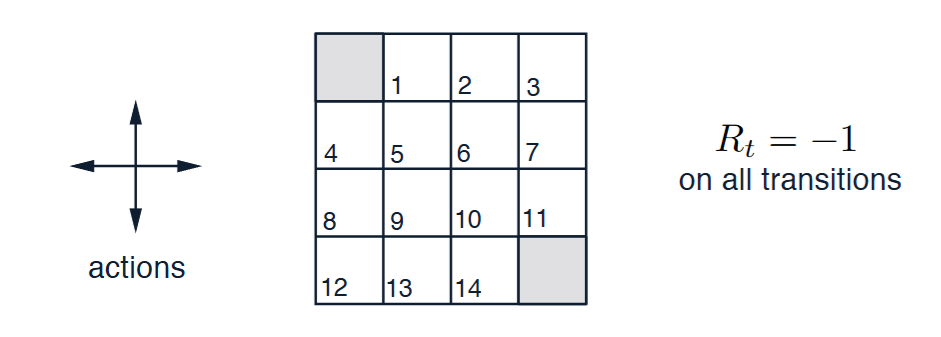

**Environment Setup:**
- **State Space ($\mathcal{S}$):** $4 \times 4$ grid ($16$ states: $(r, c) \in \{0, 1, 2, 3\} \times \{0, 1, 2, 3\}$).
- **Terminal States ($\mathcal{S}^+$):** $(0,0)$ and $(3,3)$ with $V(s) = 0$.
- **Action Space ($\mathcal{A}$):** $\{\text{Up}(\uparrow), \text{Down}(\downarrow), \text{Left}(\leftarrow), \text{Right}(\rightarrow)\}$ (deterministic transitions with boundary bounce-back).
- **Reward & Discount:** $r = -1$ for all non-terminal transitions, $\gamma = 1.0$.
- **Initial Policy ($\pi_0$):** Equiprobable random policy $\pi(a \mid s) = 0.25$.

**Policy Evaluation - Iterative Bellman Update:**
$$V_{k+1}(s) \leftarrow \sum_{a \in \mathcal{A}} \pi(a \mid s) \left[ -1 + \gamma V_k(s') \right], \quad \forall s \notin \mathcal{S}^+$$

**Greedy Policy Improvement:**
$$\pi'(s) = \arg\max_{a \in \mathcal{A}} \left[ -1 + \gamma V(s') \right]$$

# 2. **Environment: `GridWorld4x4`**

Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.patches as patches
from IPython.display import HTML, display

# Configure Matplotlib styling: serif fonts, high-DPI rendering, and readable font sizes
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12


Setup the `GridWorld` environment

In [2]:
class GridWorld4x4:
    """
    4x4 Gridworld Environment (Sutton & Barto Example 4.1).
    - States: 16 grid cells arranged in a 4x4 matrix (row r, column c).
    - Actions: 4 discrete movements: Up, Down, Left, Right.
    - Transitions: Deterministic. Moving off the grid keeps the agent in the current cell.
    - Rewards: -1 for every step until a terminal goal state is reached.
    - Terminal States: Top-left (0, 0) and Bottom-right (3, 3).
    """
    def __init__(self):
        self.grid_size = 4
        # Coordinate offsets (row change dr, column change dc)
        self.actions = {
            'U': (-1, 0),  # Move Up (decrement row)
            'D': (1, 0),   # Move Down (increment row)
            'L': (0, -1),  # Move Left (decrement column)
            'R': (0, 1)    # Move Right (increment column)
        }
        self.action_names = ['U', 'D', 'L', 'R']
        self.action_symbols = {'U': '↑', 'D': '↓', 'L': '←', 'R': '→'}
        # Goal states: (0, 0) [top-left] and (3, 3) [bottom-right]
        self.terminal_states = [(0, 0), (self.grid_size - 1, self.grid_size - 1)]
        self.reward = -1.0  # reward per step
        self.gamma = 1.0    # discount factor

    def is_terminal(self, r, c):
        """Check if cell (r, c) is one of the terminal goal states."""
        return (r, c) in self.terminal_states

    def step(self, r, c, action_name):
        """
        Execute one action from state (r, c).
        Returns:
            (next_r, next_c): New state coordinates (clipped to grid boundaries)
            reward: Scalar reward received (-1.0 or 0.0 if already terminal)
            is_terminal: Boolean flag indicating if episode ended
        """
        # Terminal states are absorbing with zero reward
        if self.is_terminal(r, c):
            return (r, c), 0.0, True    # next_state, reward, is_terminal
            
        dr, dc = self.actions[action_name]
        # Clip coordinates so the agent cannot leave the 4x4 grid
        next_r = int(np.clip(r + dr, 0, self.grid_size - 1))
        next_c = int(np.clip(c + dc, 0, self.grid_size - 1))
        
        return (next_r, next_c), self.reward, self.is_terminal(next_r, next_c)  # next_state, reward, is_terminal

# Instantiate the environment
env = GridWorld4x4()

# 3. **Policy Evaluation, Improvement & Policy Iteration**

$$
\begin{aligned}
&\boxed{\textbf{Policy Iteration (using iterative policy evaluation) for estimating } 
\pi \approx \pi_*} \\[8pt]

&\textbf{1. Initialization} \\[2pt]
&\qquad V(s) \in \mathbb{R} \text{ and } \pi(s) \in \mathcal{A}(s)
\text{ arbitrarily for all } s \in \mathcal{S} \\[10pt]

&\textbf{2. Policy Evaluation} \\[2pt]
&\qquad \text{Loop:} \\
&\qquad\qquad \Delta \leftarrow 0 \\
&\qquad\qquad \text{Loop for each } s \in \mathcal{S}: \\
&\qquad\qquad\qquad v \leftarrow V(s) \\
&\qquad\qquad\qquad V(s) \leftarrow 
\sum_{s',r} p(s',r \mid s,\pi(s))
\left[r + \gamma V(s')\right] \\
&\qquad\qquad\qquad \Delta \leftarrow 
\max\left(\Delta,\left|v-V(s)\right|\right) \\
&\qquad \text{until } \Delta < \theta
\quad \text{(a small positive number determining the accuracy of estimation)} \\[10pt]

&\textbf{3. Policy Improvement} \\[2pt]
&\qquad \mathit{policy\text{-}stable} \leftarrow \text{true} \\
&\qquad \text{For each } s \in \mathcal{S}: \\
&\qquad\qquad \mathit{old\text{-}action} \leftarrow \pi(s) \\
&\qquad\qquad \pi(s) \leftarrow 
\arg\max_a
\sum_{s',r} p(s',r \mid s,a)
\left[r+\gamma V(s')\right] \\
&\qquad\qquad \text{If } \mathit{old\text{-}action} \neq \pi(s),
\quad \mathit{policy\text{-}stable} \leftarrow \text{false} \\[5pt]

&\qquad \text{If } \mathit{policy\text{-}stable},
\text{ then stop and return } V \approx v_*
\text{ and } \pi \approx \pi_*;
\text{ else go to 2}
\end{aligned}
$$

In [3]:
def policy_evaluation(env, policy, gamma=1.0, theta=1e-4, max_sweeps=200):
    """
    Iterative Policy Evaluation (Bellman Expectation Equation):
    Computes V_pi(s) for a given policy by repeatedly sweeping over all states.
    
    Update Rule:
        V_{k+1}(s) = sum_a pi(a|s) * [ R + gamma * V_k(s') ]
        
    Stopping Criteria:
        Stops when max_s |V_{k+1}(s) - V_k(s)| < theta, or when max_sweeps is reached.
    """
    V = np.zeros((env.grid_size, env.grid_size))
    V_history = [V.copy()]  # Record initial values (k=0)
    
    for sweep in range(1, max_sweeps + 1):
        new_V = np.zeros_like(V)
        delta = 0.0  # Track maximum change in state values for convergence check
        
        # iterate through all non-terminal states
        for r in range(env.grid_size):
            for c in range(env.grid_size):
                if env.is_terminal(r, c):
                    continue
                
                # Compute expected value across all possible actions under current policy
                v_s = 0.0
                for action_idx, action_name in enumerate(env.action_names):     # over possible actions
                    (next_r, next_c), reward, _ = env.step(r, c, action_name)
                    # Bellman update
                    v_s += policy[r, c, action_idx] * (reward + gamma * V[next_r, next_c])
                
                new_V[r, c] = v_s
                delta = max(delta, abs(new_V[r, c] - V[r, c]))
                
        V = new_V
        V_history.append(V.copy())  # Save snapshot for animation
        
        # Check convergence
        if delta < theta:
            break
            
    return V, V_history

def policy_improvement(env, V, gamma=1.0, tol=1e-5):
    """
    Policy Improvement:
    Extracts the greedy policy with respect to value function V.
    Implements equiprobable tie-breaking among all actions achieving max Q(s, a).
    """
    greedy_policy = np.zeros((env.grid_size, env.grid_size, len(env.action_names)))
    
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if env.is_terminal(r, c):
                continue
            
            # Compute 1-step lookahead Q-values for all 4 actions: Q(s, a) = R + gamma * V(s')
            q_values = [env.step(r, c, a)[1] + gamma * V[env.step(r, c, a)[0]] for a in env.action_names]
            max_q = np.max(q_values)
            
            # Find all actions achieving the maximum Q-value (within numerical tolerance)
            best_acts = [i for i, q in enumerate(q_values) if np.isclose(q, max_q, atol=tol)]
            
            # Distribute probability evenly across all maximizing actions (tie-breaking)
            for idx in best_acts:
                greedy_policy[r, c, idx] = 1.0 / len(best_acts)
                
    return greedy_policy

def policy_iteration(env, gamma=1.0, theta=1e-4):
    """
    Full Policy Iteration Algorithm:
    Alternates between Policy Evaluation and Policy Improvement until policy converges.
    """
    # Start with an equiprobable random policy (25% probability for each action)
    policy = np.ones((env.grid_size, env.grid_size, len(env.action_names))) * 0.25
    history = []
    
    while True:
        # Step 1: Policy Evaluation (find V for current policy)
        V, _ = policy_evaluation(env, policy, gamma=gamma, theta=theta)
        
        # Step 2: Policy Improvement (extract greedy policy from V)
        new_policy = policy_improvement(env, V, gamma=gamma)
        history.append((policy.copy(), V.copy()))
        
        # Step 3: Policy Stability Check (stop if policy stops changing)
        if np.array_equal(policy, new_policy):
            history.append((new_policy.copy(), V.copy()))
            break
        policy = new_policy
        
    return V, policy, history

# Execute computations:
# 1. Evaluate equiprobable random policy
random_policy = np.ones((env.grid_size, env.grid_size, len(env.action_names))) * 0.25
V_converged, V_history = policy_evaluation(env, random_policy, gamma=1.0, theta=1e-4)

# 2. Run full Policy Iteration to find optimal V* and pi*
optimal_V, optimal_policy, pi_history = policy_iteration(env, gamma=1.0, theta=1e-4)

# 4. Step-Wise Visualizations

$
\text{Policy Iteration}:
\quad
\pi_0 \xrightarrow{\text{Evaluation}} v_{\pi_0} \xrightarrow{\text{Improve}} \pi_1 \xrightarrow{\text{Evaluation}} v_{\pi_1} \xrightarrow{\text{Improve}} \pi_2 \longrightarrow \pi^*, v^*
$

In [4]:
def create_policy_animation(env, V_history, dpi=150):
    """
    Creates animation comparing:
    -  Left: State-Value Heatmap
    - Right: Corresponding Greedy Policy Direction Arrows
    """
    # Sample key frames (early iterations + periodic steps + final converged state)
    frame_indices = [i for i in range(len(V_history)) if i <= 15 or i % 3 == 0 or i == len(V_history) - 1]
    policy_history = [policy_improvement(env, V_history[idx]) for idx in frame_indices]
    sampled_V = [V_history[idx] for idx in frame_indices]
    
    # Setup high-resolution dual-panel figure
    fig, (ax_val, ax_pol) = plt.subplots(1, 2, figsize=(11.8, 5.2), dpi=dpi, facecolor='#ffffff')
    suptitle = fig.suptitle(r"Sutton & Barto Ex. 4.1 • Sweep $k = 0$", 
                            fontsize=14, color="#0f172a", y=0.97, fontweight='bold')
    fig.subplots_adjust(top=0.82, bottom=0.08, left=0.06, right=0.93, wspace=0.30)
    
    # -------------------------------------------------------------
    # 1. Left Subplot: State-Value Function V_k(s)
    # -------------------------------------------------------------
    cax = ax_val.matshow(sampled_V[0], cmap='Blues_r', vmin=-22, vmax=0)
    ax_val.set_xticks(np.arange(env.grid_size) - 0.5, minor=True)
    ax_val.set_yticks(np.arange(env.grid_size) - 0.5, minor=True)
    ax_val.grid(which="minor", color="#334155", linestyle='-', linewidth=1.5)
    ax_val.tick_params(which="both", bottom=False, left=False, top=False, right=False,
                       labelbottom=False, labelleft=False, labeltop=False, labelright=False)
    ax_val.set_title(r"State-Value Function $V_k(s)$", fontsize=13, color='#0f172a', pad=14, fontweight='bold')
    
    cbar = fig.colorbar(cax, ax=ax_val, fraction=0.046, pad=0.05)
    cbar.set_label(r"Value $v_k(s)$", color="#0f172a", fontsize=11, labelpad=10)
    cbar.ax.yaxis.set_tick_params(color="#0f172a", labelsize=10)
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#0f172a')
    
    # Initialize text overlay for state values
    val_texts = []
    for r in range(env.grid_size):
        row = []
        for c in range(env.grid_size):
            t = ax_val.text(c, r, f'{sampled_V[0][r, c]:.1f}', ha="center", va="center",
                            color="#0f172a", fontweight='bold', fontsize=11.5, linespacing=1.2)
            row.append(t)
        val_texts.append(row)
        
    # -------------------------------------------------------------
    # 2. Right Subplot: Greedy Policy Direction Arrows pi_k(s)
    # -------------------------------------------------------------
    ax_pol.set_xlim(-0.5, env.grid_size - 0.5)
    ax_pol.set_ylim(env.grid_size - 0.5, -0.5)
    ax_pol.set_xticks(np.arange(env.grid_size) - 0.5, minor=True)
    ax_pol.set_yticks(np.arange(env.grid_size) - 0.5, minor=True)
    ax_pol.grid(which="minor", color="#334155", linestyle='-', linewidth=1.5)
    ax_pol.tick_params(which="both", bottom=False, left=False, top=False, right=False,
                       labelbottom=False, labelleft=False, labeltop=False, labelright=False)
    ax_pol.set_facecolor('#f8fafc')
    ax_pol.set_title(r"Greedy Policy $\pi_k(s)$", fontsize=13, color='#0f172a', pad=14, fontweight='bold')
    
    # Highlight terminal goal patches
    for tr, tc in env.terminal_states:
        rect = patches.Rectangle((tc - 0.5, tr - 0.5), 1, 1, facecolor='#e2e8f0', edgecolor='none')
        ax_pol.add_patch(rect)
        ax_pol.text(tc, tr, 'GOAL\n(T)', ha="center", va="center", color="#0f172a", fontweight='bold', fontsize=10.5, linespacing=1.2)
        
    arrow_artists = []
    offset_map = {0: (0, -0.22), 1: (0, 0.22), 2: (-0.22, 0), 3: (0.22, 0)}  # Arrow offsets for ties
    arrow_sym = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    
    def animate_frame(frame_idx):
        """Updates state values, colormap, title, and policy arrows for each frame."""
        k_val = frame_indices[frame_idx]
        current_V = sampled_V[frame_idx]
        current_pol = policy_history[frame_idx]
        
        # Update value matrix and banner title
        cax.set_data(current_V)
        tag = f"$k = {k_val}$" if k_val < len(V_history) - 1 else r"$k = \infty$ (Converged)"
        suptitle.set_text(f"Sutton & Barto Ex. 4.1 • Policy Iteration for {tag}")
        
        # Update numeric text in value grid
        for r in range(env.grid_size):
            for c in range(env.grid_size):
                val = current_V[r, c]
                if env.is_terminal(r, c):
                    val_texts[r][c].set_text("0.0\n(T)")
                    val_texts[r][c].set_color("#0f172a")
                else:
                    val_texts[r][c].set_text(f"{val:.1f}")
                    # Contrast adjustment for darker blue backgrounds
                    val_texts[r][c].set_color("white" if val < -10 else "#0f172a")
                    
        # Clear previous arrows
        nonlocal arrow_artists
        for art in arrow_artists:
            art.remove()
        arrow_artists = []
        
        # Draw new greedy policy arrows
        for r in range(env.grid_size):
            for c in range(env.grid_size):
                if env.is_terminal(r, c):
                    continue
                # For k=0, show all 4 arrows (equiprobable); otherwise show greedy actions
                best_acts = [0, 1, 2, 3] if k_val == 0 else [i for i, p in enumerate(current_pol[r, c]) if p > 0]
                arrow_color = "#64748b" if k_val == 0 else "#1d4ed8"
                for act_idx in best_acts:
                    dx, dy = offset_map[act_idx]
                    art = ax_pol.text(c + dx, r + dy, arrow_sym[act_idx], ha="center", va="center",
                                      color=arrow_color, fontsize=16.5, fontweight='bold')
                    arrow_artists.append(art)
                    
        return [cax, suptitle]
        
    anim = animation.FuncAnimation(fig, animate_frame, frames=len(frame_indices), interval=600, blit=False)
    plt.close(fig)
    return anim

# Generate animation object
anim_eval = create_policy_animation(env, V_history, dpi=150)

# Save the animation locally as HD GIF
gif_path = 'content/policy_iteration_animation.gif'
writer = animation.PillowWriter(fps=4)
anim_eval.save(gif_path, writer=writer, dpi=120)

# Display animated GIF in notebook
display(HTML(f'<img src="{gif_path}" width="100%" alt="Policy Iteration Animation" />'))

---
<div style="text-align: center; color: #94a3b8; font-size: 0.85rem; margin-top: 16px;">
  AI31201 Reinforcement Learning • Autumn 2026 • IIT Kharagpur
</div>